In [ ]:
import pandas as pd
df = pd.read_excel('Wheat_modelling_data.xlsx')

In [ ]:
# Continuous variable used to DEFINE classes (clustered on train only)
y_cont = df["Bread_Volume_2"]

# Predictors (remove targets and any non-predictors)
# IMPORTANT: do NOT include Bread_Volume_2 itself as a predictor
drop_cols = ['YEAR', 'Growout', 'Sample ID', 'GIPSA Classification',
        'RVA-Peak time (min)',
       'RVA-Peak viscosity (RVU)', 'RVA-Breakdown (RVU)',
       'RVA-Final viscosity at 13 min (RVU)', 'L*', 'a*', 'b*', 'HMW-GS Composition',
       'Glu-A1', 'Glu-B1', 'Glu-D1',
       'Bread_Volume_2', 'overall bread quality', 'Crumb grain ',
       'crumb texture'] 
X_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Keep only rows with complete y_cont and predictors
mask = y_cont.notna() & X_df.notna().all(axis=1)
X_df = X_df.loc[mask].copy()
y_cont = y_cont.loc[mask].copy()

print(X_df.shape, y_cont.shape)


K-MEANS TRAINING


In [3]:
import numpy as np
from sklearn.cluster import KMeans
def fit_kmeans_cutoffs_1d(y_train_cont: np.ndarray, k: int = 3, random_state: int = 42):
    """
    Fit 1D KMeans on TRAIN ONLY and derive cutoffs between sorted centroids.
    Returns: centroids_sorted, cut1, cut2
    """
    y = np.asarray(y_train_cont).reshape(-1, 1)

    km = KMeans(n_clusters=k, n_init=25, random_state=random_state)
    km.fit(y)

    centroids = np.sort(km.cluster_centers_.ravel())
    # cutoffs are midpoints between adjacent centroids
    cut1 = 0.5 * (centroids[0] + centroids[1])
    cut2 = 0.5 * (centroids[1] + centroids[2])
    return centroids, cut1, cut2


def assign_volume_class(y_continuous: np.ndarray, cut1: float, cut2: float):
    """
    Apply train-derived cutoffs to any y array to produce labels.
    """
    y = np.asarray(y_continuous)
    out = np.empty(y.shape, dtype=object)
    out[y < cut1] = "Low"
    out[(y >= cut1) & (y < cut2)] = "Moderate"
    out[y >= cut2] = "High"
    return out


Train-only feature selection (corr-filter + MI top-K), k=10



In [4]:
from sklearn.feature_selection import mutual_info_classif

def corr_filter_train_only(X_train: pd.DataFrame, thresh: float = 0.85):
    corr = X_train.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if (upper[col] >= thresh).any()]
    X_red = X_train.drop(columns=to_drop, errors="ignore")
    return X_red, to_drop


def mi_top_k_train_only(X_train: pd.DataFrame, y_train_labels: np.ndarray, k: int = 10, random_state: int = 42):
    """
    MI for classification: mutual_info_classif.
    """
    mi = mutual_info_classif(X_train, y_train_labels, random_state=random_state)
    mi_s = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
    top_feats = mi_s.index[:k].tolist()
    return top_feats, mi_s


def select_features_train_only(X_train: pd.DataFrame, y_train_labels: np.ndarray,
                               corr_thresh: float = 0.85, top_k: int = 15, random_state: int = 42):
    X_red, dropped = corr_filter_train_only(X_train, thresh=corr_thresh)
    k_use = min(top_k, X_red.shape[1])
    top_feats, mi_scores = mi_top_k_train_only(X_red, y_train_labels, k=k_use, random_state=random_state)
    kept_after_corr = X_red.columns.tolist()
    return top_feats, dropped, mi_scores, kept_after_corr


In [ ]:
# =========================
# Gradient Boosting chunk (sklearn)
# Works with the SAME: outer CV + train-only KMeans cutoffs + optional corr+MI top-k selection
# =========================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# ---- Settings (reuse yours if already defined) ----
outer_splits = 5
rng = 42
corr_thresh = 0.85
top_k = 15
LABELS = ["Low", "Moderate", "High"]

# Stratify outer folds using quantile bins of y_cont (continuous target)
strat_bins = pd.qcut(y_cont, q=3, labels=["Lbin", "Mbin", "Hbin"])
outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=rng)

# ---- Gradient Boosting model ----
gb_sklearn = GradientBoostingClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,            # depth of individual trees
    subsample=0.8,          # stochastic gradient boosting
    random_state=rng
)

# Pipeline: impute then Gradient Boosting
pipe_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("gb", gb_sklearn),
])

def eval_sklearn_gb_outer_cv(X_df, y_cont, use_selected: bool):
    fold_f1 = []
    y_all, yhat_all = [], []
    selected_feats_per_fold = []

    # feature importance aggregation across folds
    featimp_rows = []  # list of pd.Series indexed by feature name

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_df, strat_bins), start=1):
        X_train, X_test = X_df.iloc[tr_idx].copy(), X_df.iloc[te_idx].copy()
        y_train_cont = y_cont.iloc[tr_idx].values
        y_test_cont  = y_cont.iloc[te_idx].values

        # --- Train-only KMeans cutoffs -> labels (no leakage) ---
        centroids, cut1, cut2 = fit_kmeans_cutoffs_1d(y_train_cont, k=3, random_state=rng)
        y_train = assign_volume_class(y_train_cont, cut1, cut2)
        y_test  = assign_volume_class(y_test_cont,  cut1, cut2)

        # --- Optional train-only feature selection ---
        if use_selected:
            top_feats, dropped, mi_scores, kept_after_corr = select_features_train_only(
                X_train, y_train, corr_thresh=corr_thresh, top_k=top_k, random_state=rng
            )
            X_train_use = X_train[kept_after_corr][top_feats]
            X_test_use  = X_test[kept_after_corr][top_feats]
            selected_feats_per_fold.append(list(top_feats))
            feat_tag = f"SEL(k={len(top_feats)})"
        else:
            X_train_use, X_test_use = X_train, X_test
            feat_tag = f"ALL(p={X_train.shape[1]})"

        # --- Fit + predict ---
        pipe_gb.fit(X_train_use, y_train)
        y_pred = pipe_gb.predict(X_test_use)

        # --- Metrics ---
        f1m = f1_score(y_test, y_pred, average="macro", labels=LABELS, zero_division=0)
        fold_f1.append(f1m)

        # pooled predictions
        y_all.extend(list(y_test))
        yhat_all.extend(list(y_pred))

        # --- Feature importance (GBDT has feature_importances_) ---
        gb = pipe_gb.named_steps["gb"]
        fi = pd.Series(gb.feature_importances_, index=X_train_use.columns, name=f"fold{fold}")
        featimp_rows.append(fi)

        print(f"[GB {feat_tag} | Fold {fold}] macro-F1={f1m:.3f} | cut1={cut1:.2f}, cut2={cut2:.2f}")

    pooled_f1 = f1_score(y_all, yhat_all, average="macro", labels=LABELS, zero_division=0)
    pooled_cm = confusion_matrix(y_all, yhat_all, labels=LABELS)

    print("\n=== sklearn GRADIENT BOOSTING SUMMARY:", ("SELECTED" if use_selected else "ALL"), "===")
    print(f"macro-F1 mean±sd: {np.mean(fold_f1):.3f} ± {np.std(fold_f1, ddof=1):.3f}")
    print(f"macro-F1 pooled:  {pooled_f1:.3f}")
    print("Pooled CM (rows=true, cols=pred; Low/Moderate/High):\n", pooled_cm)
    print("\nPooled classification report:")
    print(classification_report(y_all, yhat_all, labels=LABELS, digits=3, zero_division=0))

    return {
        "fold_f1": fold_f1,
        "pooled_f1": pooled_f1,
        "pooled_cm": pooled_cm,
        "y_all": np.array(y_all),
        "yhat_all": np.array(yhat_all),
        "selected_feats_per_fold": selected_feats_per_fold,
        "featimp_rows": featimp_rows
    }

def summarize_gb_importance(featimp_rows, top_n=20):
    """Mean±SD of feature_importances_ across folds."""
    if len(featimp_rows) == 0:
        print("No feature-importance rows collected.")
        return None
    FI = pd.concat(featimp_rows, axis=1).fillna(0.0)
    out = pd.DataFrame({
        "mean_importance": FI.mean(axis=1),
        "std_importance":  FI.std(axis=1)
    }).sort_values("mean_importance", ascending=False).head(top_n)
    return out

# ---- Run GB outer-CV (ALL and SELECTED) ----
gb_all = eval_sklearn_gb_outer_cv(X_df, y_cont, use_selected=False)
gb_sel = eval_sklearn_gb_outer_cv(X_df, y_cont, use_selected=True)

print("\nTop important features (GB-ALL):")
display(summarize_gb_importance(gb_all["featimp_rows"], top_n=20))

print("\nTop important features (GB-SELECTED):")
display(summarize_gb_importance(gb_sel["featimp_rows"], top_n=20))

# Optional: selection frequency for SELECTED
if len(gb_sel["selected_feats_per_fold"]) > 0:
    freq = (pd.Series([f for L in gb_sel["selected_feats_per_fold"] for f in L])
              .value_counts() / outer_splits)
    print("\nTop selected features across folds (frequency):")
    display(freq.head(30))


[GB ALL(p=39) | Fold 1] macro-F1=0.680 | cut1=940.89, cut2=1074.26
[GB ALL(p=39) | Fold 2] macro-F1=0.730 | cut1=942.27, cut2=1084.65
[GB ALL(p=39) | Fold 3] macro-F1=0.713 | cut1=942.80, cut2=1085.87
[GB ALL(p=39) | Fold 4] macro-F1=0.658 | cut1=946.44, cut2=1097.90
[GB ALL(p=39) | Fold 5] macro-F1=0.601 | cut1=942.32, cut2=1085.79

=== sklearn GRADIENT BOOSTING SUMMARY: ALL ===
macro-F1 mean±sd: 0.676 ± 0.050
macro-F1 pooled:  0.691
Pooled CM (rows=true, cols=pred; Low/Moderate/High):
 [[ 94  37   0]
 [ 27 129  10]
 [  1  18  21]]

Pooled classification report:
              precision    recall  f1-score   support

         Low      0.770     0.718     0.743       131
    Moderate      0.701     0.777     0.737       166
        High      0.677     0.525     0.592        40

    accuracy                          0.724       337
   macro avg      0.716     0.673     0.691       337
weighted avg      0.725     0.724     0.722       337

[GB SEL(k=15) | Fold 1] macro-F1=0.675 | cut1=940

,mean_importance,std_importance
Sedimentation_test,0.114357,0.034817
AL_Extensibility,0.066685,0.020625
TPP/TMP,0.055581,0.021136
Fari_Breakdown time (min),0.050488,0.032514
Al_Elasticity Index,0.047108,0.011380
Hectoliter Weight (kg/hl),0.042786,0.016814
EX_Energy,0.040755,0.021062
Fari_Mix stability (min),0.034991,0.017102
Wheat_Protein,0.032097,0.007641
Flour_moisture,0.031330,0.011707



Top important features (GB-SELECTED):


,mean_importance,std_importance
Sedimentation_test,0.150843,0.036389
AL_Extensibility,0.118501,0.067829
Fari_Mix stability (min),0.075195,0.019625
TPP/TMP,0.074108,0.048031
Al_Elasticity Index,0.073048,0.017830
Damaged Starch (%),0.065610,0.019313
Wheat_Protein,0.061163,0.009370
EX_Energy,0.054387,0.016299
Hectoliter Weight (kg/hl),0.052683,0.048657
Fari_Peak_time,0.041305,0.041911



Top selected features across folds (frequency):


Sedimentation_test                  1.0
Al_Elasticity Index                 1.0
EX_Energy                           1.0
Fari_Mix stability (min)            1.0
Damaged Starch (%)                  1.0
Wheat_Protein                       1.0
AL_Extensibility                    0.8
Mixo_Mix_Tolerance                  0.8
Fari_Mix Tolerance Index (FU)       0.8
TPP/TMP                             0.8
Flour Yield (Quadrumat Sr. Mill)    0.6
Fari_Flour Abs (14% mb)             0.6
Hectoliter Weight (kg/hl)           0.6
Wheat_moisture                      0.6
Fari_Peak_time                      0.6
Kernel_Hardness                     0.4
Test Weight (lb/bu)                 0.4
EX_Extensibility                    0.4
PPO                                 0.4
Mixo_Mix_Time                       0.2
Flour_moisture                      0.2
Flour-ash                           0.2
Falling number                      0.2
AL_Strenght                         0.2
EX_Resist                           0.2


KMeans cutoffs (FULL train): cut1=943.6781, cut2=1086.3443
Class counts: {'Moderate bread volume': 166, 'Low bread volume': 131, 'High bread volume': 40}

=== FINAL FEATURE SELECTION (FULL TRAIN) ===
Original predictors: 39
Dropped by corr (>0.85): 9
Remaining after corr: 30
Top-K requested: 15 | Top-K returned: 15

Top features (MI ranking):
['Sedimentation_test', 'EX_Energy', 'Fari_Mix stability (min)', 'Wheat_Protein', 'Al_Elasticity Index', 'Damaged Starch (%)', 'Fari_Peak_time', 'AL_Extensibility', 'Test Weight (lb/bu)', 'TPP/TMP', 'EX_Extensibility', 'Mixo_Mix_Time', 'Fari_Mix Tolerance Index (FU)', 'Kernel_Hardness', 'Hectoliter Weight (kg/hl)']

Top MI scores (selected):


Sedimentation_test               0.165995
EX_Energy                        0.149098
Fari_Mix stability (min)         0.147586
Wheat_Protein                    0.146322
Al_Elasticity Index              0.135627
Damaged Starch (%)               0.126241
Fari_Peak_time                   0.093783
AL_Extensibility                 0.088716
Test Weight (lb/bu)              0.087939
TPP/TMP                          0.069901
EX_Extensibility                 0.067479
Mixo_Mix_Time                    0.065283
Fari_Mix Tolerance Index (FU)    0.063400
Kernel_Hardness                  0.057978
Hectoliter Weight (kg/hl)        0.057351
dtype: float64

predict_proba OK. shape: (5, 3)

Fitted final model: GBM | features used: 15
GB classes_: ['High bread volume', 'Low bread volume', 'Moderate bread volume']
SHAP background rows: 100 | explain rows: 200


PermutationExplainer explainer: 201it [02:26,  1.34it/s]                         


Plotting class: High bread volume


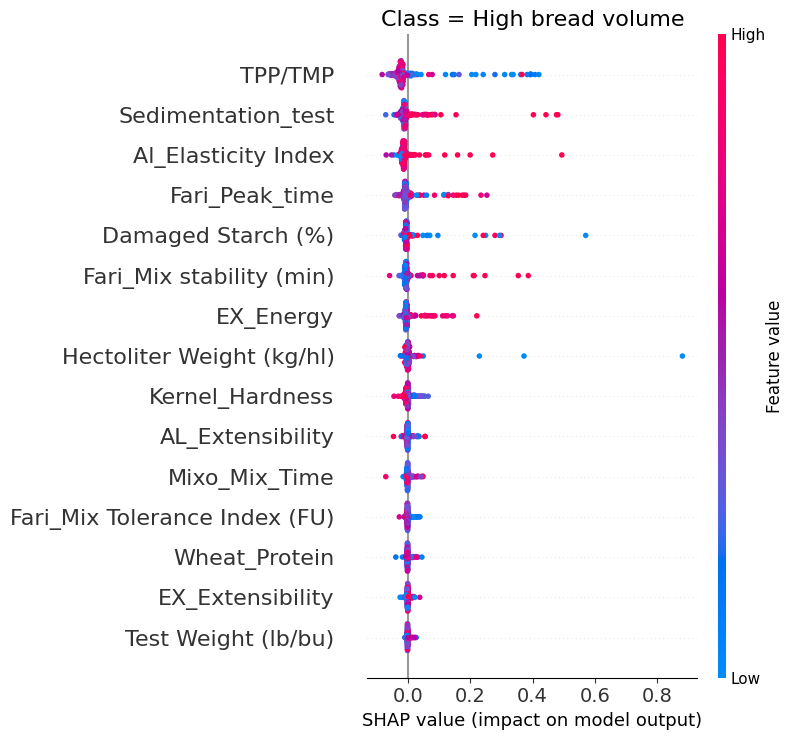

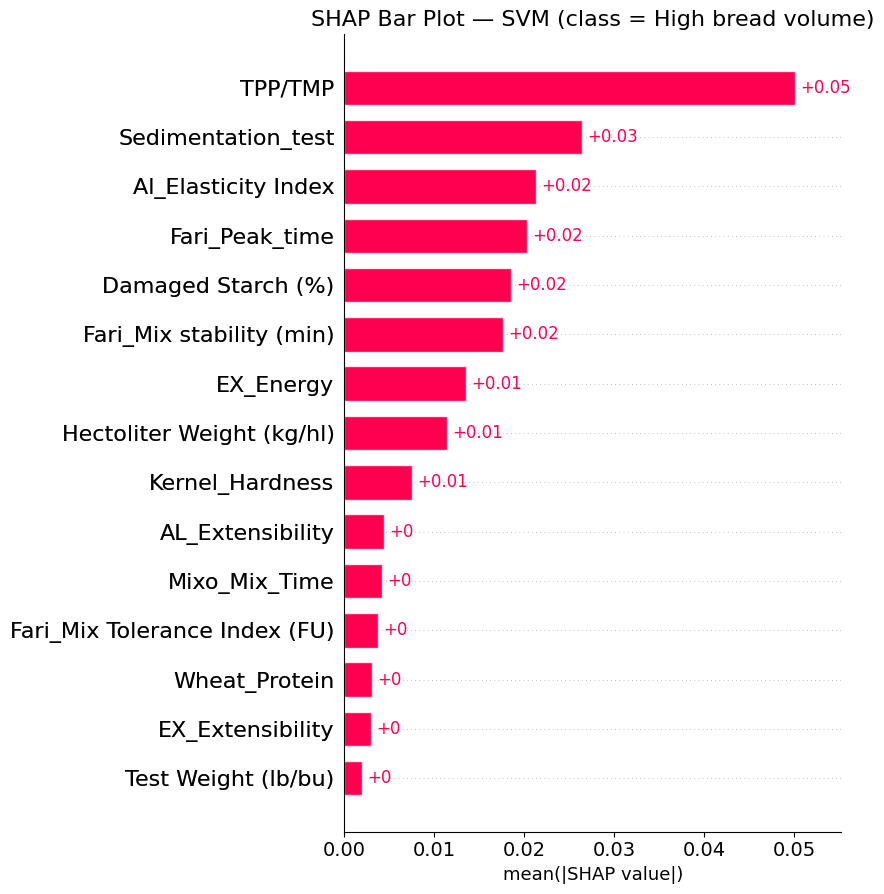

In [7]:


import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# -------------------------
# Settings
# -------------------------
top_k = 15
corr_thresh = 0.85
rng = 42
LABELS = ["Low bread volume", "Moderate bread volume", "High bread volume"]
class_name = "High bread volume"           # <-- plot/explain this class

# -------------------------
# Helper: assign 3-class labels from 2 cutoffs
# -------------------------
def assign_3class_from_cutoffs(y, cut1, cut2, labels=("Low bread volume", "Moderate bread volume", "High bread volume")):
    y = np.asarray(y, dtype=float)
    lo, mid, hi = labels
    out = np.empty(len(y), dtype=object)
    out[y <= cut1] = lo
    out[(y > cut1) & (y <= cut2)] = mid
    out[y > cut2] = hi
    return out

# -------------------------
# 1) Labels from FULL training (k=3)
# -------------------------
# expects your function returns (centers, cut1, cut2) for k=3
_, cut1, cut2 = fit_kmeans_cutoffs_1d(y_cont.values, k=3, random_state=rng)

# If you already have your own assign function for 3 classes, use it instead.
y_train_lbl = assign_3class_from_cutoffs(y_cont.values, cut1, cut2, labels=LABELS)

print(f"KMeans cutoffs (FULL train): cut1={cut1:.4f}, cut2={cut2:.4f}")
print("Class counts:", pd.Series(y_train_lbl).value_counts().to_dict())

# -------------------------
# 2) Corr + MI Top-K on FULL training
# -------------------------
top_feats, dropped, mi_scores, kept_after_corr = select_features_train_only(
    X_df, y_train_lbl, corr_thresh=corr_thresh, top_k=top_k, random_state=rng
)

X_train_use = X_df.loc[:, kept_after_corr].loc[:, top_feats]

print("\n=== FINAL FEATURE SELECTION (FULL TRAIN) ===")
print("Original predictors:", X_df.shape[1])
print(f"Dropped by corr (>{corr_thresh}): {len(dropped)}")
print("Remaining after corr:", len(kept_after_corr))
print(f"Top-K requested: {top_k} | Top-K returned: {len(top_feats)}")
print("\nTop features (MI ranking):")
print(top_feats)
print("\nTop MI scores (selected):")
display(mi_scores.loc[top_feats])

# -------------------------
# 3) Fit FINAL SVM (pipeline)
# -------------------------
# IMPORTANT for SHAP: need predict_proba -> set probability=True in SVC
# Ensure your pipeline uses an SVC with probability=True
# Example: pipe_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, ...))])
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Example: rebuild pipe_svm correctly (edit names to match yours)
pipe_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("gb", gb_sklearn),
])

# Refit on your selected features
pipe_gb.fit(X_train_use, y_train_lbl)

# Now this works
proba = pipe_gb.predict_proba(X_train_use.iloc[:5])
print("predict_proba OK. shape:", proba.shape)
model_name = "GBM"
pipe_final = pipe_gb
pipe_final.fit(X_train_use, y_train_lbl)

gb_est = pipe_final.named_steps.get("gb", None)
if gb_est is None:
    raise ValueError("Pipeline must have a GB step named 'gb' (pipe_final.named_steps['gb']).")

print(f"\nFitted final model: {model_name} | features used: {X_train_use.shape[1]}")
print("GB classes_:", list(getattr(gb_est, "classes_", [])))

# -------------------------
# 4) Background + explain sets
# -------------------------
max_background = 100   # Kernel SHAP is expensive for SVM; keep modest
max_explain = 200

X_bg = X_train_use.sample(n=min(max_background, len(X_train_use)), random_state=rng)
X_explain = X_train_use.sample(n=min(max_explain, len(X_train_use)), random_state=rng + 1)

print(f"SHAP background rows: {len(X_bg)} | explain rows: {len(X_explain)}")

# -------------------------
# 5) SHAP (SVM) — robust multiclass handling
# -------------------------
# We explain probabilities for multiclass: f(x) = predict_proba(x)
f = pipe_final.predict_proba  # uses scaler + svm inside pipeline

# Prefer shap.Explainer (auto-selects appropriate explainer); fallback to KernelExplainer if needed.
try:
    explainer = shap.Explainer(f, X_bg)          # often uses KernelExplainer internally for SVM
    sv = explainer(X_explain)                    # shap.Explanation
except Exception as e:
    print("shap.Explainer failed; falling back to shap.KernelExplainer. Reason:", repr(e))
    explainer = shap.KernelExplainer(f, X_bg)
    # nsamples controls approximation quality/cost
    shap_values = explainer.shap_values(X_explain, nsamples=200)
    # KernelExplainer returns list[n_classes] of arrays (n_samples, n_features)
    # We'll convert to a unified Explanation-like structure below.
    sv = shap_values  # keep as list; handled later

# Choose the class index for "High"
classes = list(getattr(gb_est, "classes_", LABELS))
class_idx = classes.index(class_name) if class_name in classes else (len(classes) - 1)
print("Plotting class:", classes[class_idx])

# -------------------------
# 6) Slice to class = "High" and plot
# -------------------------
# Case A: sv is shap.Explanation from shap.Explainer
if hasattr(sv, "values"):
    # Possible shapes:
    # - (n, p) for single-output
    # - (n, p, k) for multiclass
    if sv.values.ndim == 3:
        sv_1 = shap.Explanation(
            values=sv.values[:, :, class_idx],
            base_values=(sv.base_values[:, class_idx]
                         if np.ndim(sv.base_values) == 2 else sv.base_values),
            data=sv.data,
            feature_names=sv.feature_names
        )
    else:
        sv_1 = sv

    shap.plots.beeswarm(sv_1, max_display=15, show=False)
    plt.title(f"Class = {classes[class_idx]}", fontsize=16)
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=14)
    plt.tight_layout()
    plt.show()

    shap.plots.bar(sv_1, max_display=15, show=False)
    plt.title(f"SHAP Global Importance — SVM (class = {classes[class_idx]})", fontsize=16)
    plt.tight_layout()
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=14)
    plt.title(f"SHAP Bar Plot — SVM (class = {classes[class_idx]})", fontsize=16)
    plt.show()

# Case B: sv is list of arrays from KernelExplainer
else:
    sv_class = sv[class_idx]  # (n_samples, n_features)

    # Beeswarm-like summary (works reliably for KernelExplainer outputs)
    shap.summary_plot(
        sv_class, X_explain, feature_names=X_explain.columns,
        max_display=15, show=True
    )
    plt.title(f"SHAP Summary — SVM (class = {classes[class_idx]})")
    plt.tight_layout()
    plt.show()

    # Bar plot of mean(|SHAP|) for this class
    mean_abs = np.abs(sv_class).mean(axis=0)
    imp = pd.Series(mean_abs, index=X_explain.columns).sort_values(ascending=False).head(15)
    imp.iloc[::-1].plot(kind="barh")
    plt.title(f"Mean(|SHAP|) — SVM (class = {classes[class_idx]})")
    plt.xlabel("Mean |SHAP|")
    plt.tight_layout()
    plt.show()

KMeans cutoffs (FULL train): cut1=943.6781, cut2=1086.3443
Class counts: {'Moderate bread volume': 166, 'Low bread volume': 131, 'High bread volume': 40}

=== FINAL FEATURE SELECTION (FULL TRAIN) ===
Original predictors: 39
Dropped by corr (>0.85): 9
Remaining after corr: 30
Top-K requested: 15 | Top-K returned: 15

Top features (MI ranking):
['Sedimentation_test', 'EX_Energy', 'Fari_Mix stability (min)', 'Wheat_Protein', 'Al_Elasticity Index', 'Damaged Starch (%)', 'Fari_Peak_time', 'AL_Extensibility', 'Test Weight (lb/bu)', 'TPP/TMP', 'EX_Extensibility', 'Mixo_Mix_Time', 'Fari_Mix Tolerance Index (FU)', 'Kernel_Hardness', 'Hectoliter Weight (kg/hl)']

Top MI scores (selected):


Sedimentation_test               0.165995
EX_Energy                        0.149098
Fari_Mix stability (min)         0.147586
Wheat_Protein                    0.146322
Al_Elasticity Index              0.135627
Damaged Starch (%)               0.126241
Fari_Peak_time                   0.093783
AL_Extensibility                 0.088716
Test Weight (lb/bu)              0.087939
TPP/TMP                          0.069901
EX_Extensibility                 0.067479
Mixo_Mix_Time                    0.065283
Fari_Mix Tolerance Index (FU)    0.063400
Kernel_Hardness                  0.057978
Hectoliter Weight (kg/hl)        0.057351
dtype: float64

predict_proba OK. shape: (5, 3)

Fitted final model: GBM | features used: 15
GB classes_: ['High bread volume', 'Low bread volume', 'Moderate bread volume']
SHAP background rows: 100 | explain rows: 200


PermutationExplainer explainer: 201it [02:20,  1.38it/s]                         


Plotting class: Low bread volume


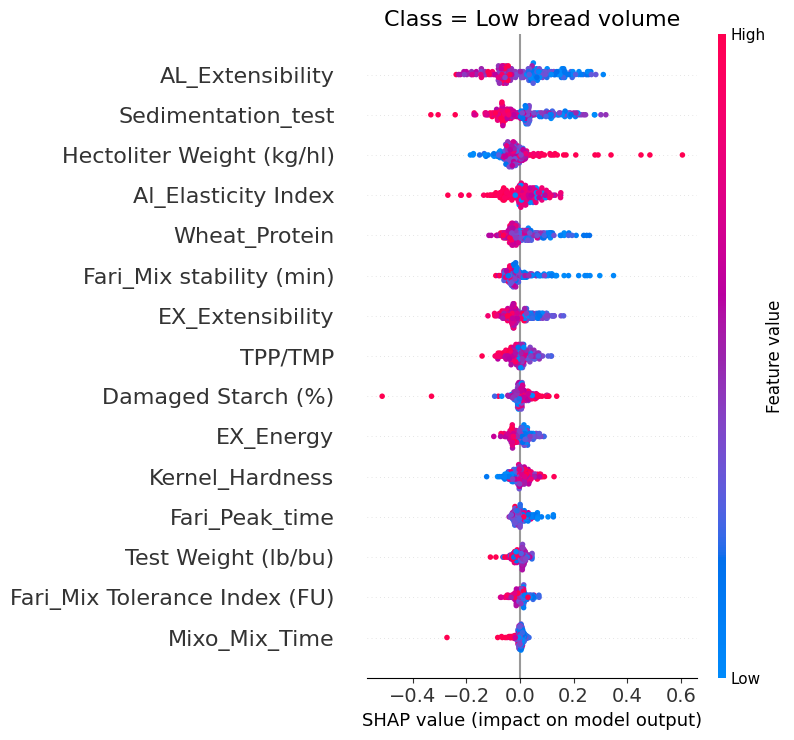

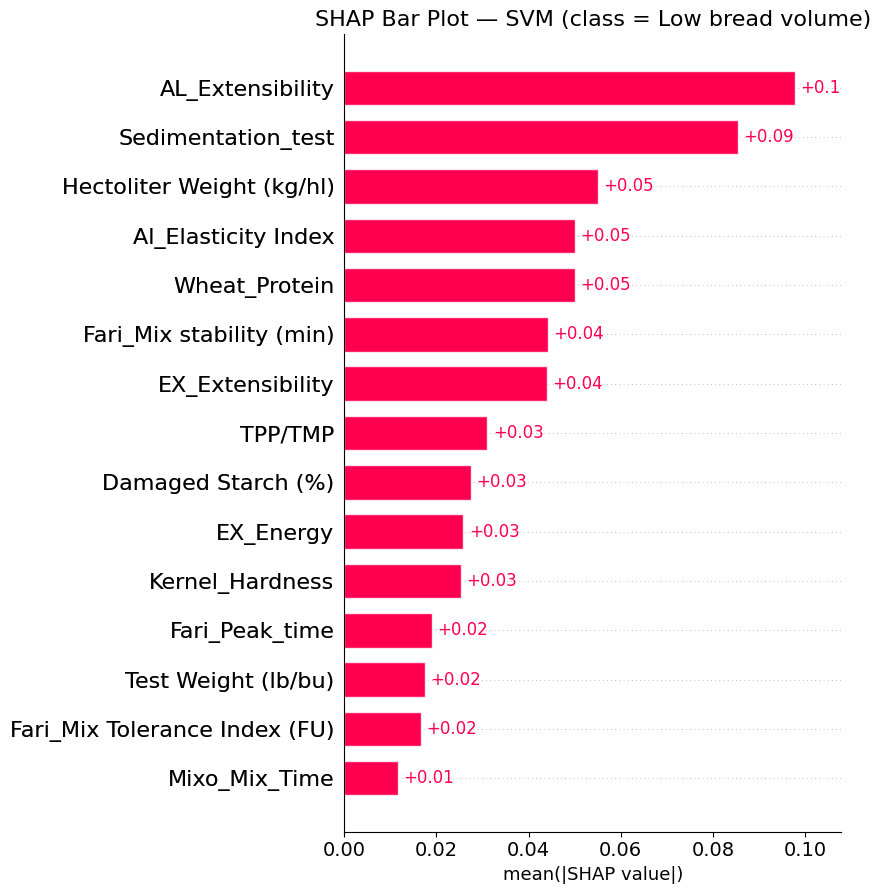

In [6]:


import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# -------------------------
# Settings
# -------------------------
top_k = 15
corr_thresh = 0.85
rng = 42
LABELS = ["Low bread volume", "Moderate bread volume", "High bread volume"]
class_name = "Low bread volume"           # <-- plot/explain this class

# -------------------------
# Helper: assign 3-class labels from 2 cutoffs
# -------------------------
def assign_3class_from_cutoffs(y, cut1, cut2, labels=("Low bread volume", "Moderate bread volume", "High bread volume")):
    y = np.asarray(y, dtype=float)
    lo, mid, hi = labels
    out = np.empty(len(y), dtype=object)
    out[y <= cut1] = lo
    out[(y > cut1) & (y <= cut2)] = mid
    out[y > cut2] = hi
    return out

# -------------------------
# 1) Labels from FULL training (k=3)
# -------------------------
# expects your function returns (centers, cut1, cut2) for k=3
_, cut1, cut2 = fit_kmeans_cutoffs_1d(y_cont.values, k=3, random_state=rng)

# If you already have your own assign function for 3 classes, use it instead.
y_train_lbl = assign_3class_from_cutoffs(y_cont.values, cut1, cut2, labels=LABELS)

print(f"KMeans cutoffs (FULL train): cut1={cut1:.4f}, cut2={cut2:.4f}")
print("Class counts:", pd.Series(y_train_lbl).value_counts().to_dict())

# -------------------------
# 2) Corr + MI Top-K on FULL training
# -------------------------
top_feats, dropped, mi_scores, kept_after_corr = select_features_train_only(
    X_df, y_train_lbl, corr_thresh=corr_thresh, top_k=top_k, random_state=rng
)

X_train_use = X_df.loc[:, kept_after_corr].loc[:, top_feats]

print("\n=== FINAL FEATURE SELECTION (FULL TRAIN) ===")
print("Original predictors:", X_df.shape[1])
print(f"Dropped by corr (>{corr_thresh}): {len(dropped)}")
print("Remaining after corr:", len(kept_after_corr))
print(f"Top-K requested: {top_k} | Top-K returned: {len(top_feats)}")
print("\nTop features (MI ranking):")
print(top_feats)
print("\nTop MI scores (selected):")
display(mi_scores.loc[top_feats])

# -------------------------
# 3) Fit FINAL SVM (pipeline)
# -------------------------
# IMPORTANT for SHAP: need predict_proba -> set probability=True in SVC
# Ensure your pipeline uses an SVC with probability=True
# Example: pipe_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, ...))])
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Example: rebuild pipe_svm correctly (edit names to match yours)
pipe_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("gb", gb_sklearn),
])

# Refit on your selected features
pipe_gb.fit(X_train_use, y_train_lbl)

# Now this works
proba = pipe_gb.predict_proba(X_train_use.iloc[:5])
print("predict_proba OK. shape:", proba.shape)
model_name = "GBM"
pipe_final = pipe_gb
pipe_final.fit(X_train_use, y_train_lbl)

gb_est = pipe_final.named_steps.get("gb", None)
if gb_est is None:
    raise ValueError("Pipeline must have a GB step named 'gb' (pipe_final.named_steps['gb']).")

print(f"\nFitted final model: {model_name} | features used: {X_train_use.shape[1]}")
print("GB classes_:", list(getattr(gb_est, "classes_", [])))

# -------------------------
# 4) Background + explain sets
# -------------------------
max_background = 100   # Kernel SHAP is expensive for SVM; keep modest
max_explain = 200

X_bg = X_train_use.sample(n=min(max_background, len(X_train_use)), random_state=rng)
X_explain = X_train_use.sample(n=min(max_explain, len(X_train_use)), random_state=rng + 1)

print(f"SHAP background rows: {len(X_bg)} | explain rows: {len(X_explain)}")

# -------------------------
# 5) SHAP (SVM) — robust multiclass handling
# -------------------------
# We explain probabilities for multiclass: f(x) = predict_proba(x)
f = pipe_final.predict_proba  # uses scaler + svm inside pipeline

# Prefer shap.Explainer (auto-selects appropriate explainer); fallback to KernelExplainer if needed.
try:
    explainer = shap.Explainer(f, X_bg)          # often uses KernelExplainer internally for SVM
    sv = explainer(X_explain)                    # shap.Explanation
except Exception as e:
    print("shap.Explainer failed; falling back to shap.KernelExplainer. Reason:", repr(e))
    explainer = shap.KernelExplainer(f, X_bg)
    # nsamples controls approximation quality/cost
    shap_values = explainer.shap_values(X_explain, nsamples=200)
    # KernelExplainer returns list[n_classes] of arrays (n_samples, n_features)
    # We'll convert to a unified Explanation-like structure below.
    sv = shap_values  # keep as list; handled later

# Choose the class index for "High"
classes = list(getattr(gb_est, "classes_", LABELS))
class_idx = classes.index(class_name) if class_name in classes else (len(classes) - 1)
print("Plotting class:", classes[class_idx])

# -------------------------
# 6) Slice to class = "High" and plot
# -------------------------
# Case A: sv is shap.Explanation from shap.Explainer
if hasattr(sv, "values"):
    # Possible shapes:
    # - (n, p) for single-output
    # - (n, p, k) for multiclass
    if sv.values.ndim == 3:
        sv_1 = shap.Explanation(
            values=sv.values[:, :, class_idx],
            base_values=(sv.base_values[:, class_idx]
                         if np.ndim(sv.base_values) == 2 else sv.base_values),
            data=sv.data,
            feature_names=sv.feature_names
        )
    else:
        sv_1 = sv

    shap.plots.beeswarm(sv_1, max_display=15, show=False)
    plt.title(f"Class = {classes[class_idx]}", fontsize=16)
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=14)
    plt.tight_layout()
    plt.show()

    shap.plots.bar(sv_1, max_display=15, show=False)
    plt.title(f"SHAP Global Importance — SVM (class = {classes[class_idx]})", fontsize=16)
    plt.tight_layout()
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=14)
    plt.title(f"SHAP Bar Plot — SVM (class = {classes[class_idx]})", fontsize=16)
    plt.show()

# Case B: sv is list of arrays from KernelExplainer
else:
    sv_class = sv[class_idx]  # (n_samples, n_features)

    # Beeswarm-like summary (works reliably for KernelExplainer outputs)
    shap.summary_plot(
        sv_class, X_explain, feature_names=X_explain.columns,
        max_display=15, show=True
    )
    plt.title(f"SHAP Summary — SVM (class = {classes[class_idx]})")
    plt.tight_layout()
    plt.show()

    # Bar plot of mean(|SHAP|) for this class
    mean_abs = np.abs(sv_class).mean(axis=0)
    imp = pd.Series(mean_abs, index=X_explain.columns).sort_values(ascending=False).head(15)
    imp.iloc[::-1].plot(kind="barh")
    plt.title(f"Mean(|SHAP|) — SVM (class = {classes[class_idx]})")
    plt.xlabel("Mean |SHAP|")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

# validation data
val = pd.read_excel(
    'Wheat-validation-data.xlsx'
)

# Continuous variable for validation
y_val_cont = val["Bread_Volume_2"].copy()

drop_cols = ['YEAR', 'Growout', 'Sample ID', 'GIPSA Classification',
        'RVA-Peak time (min)',
       'RVA-Peak viscosity (RVU)', 'RVA-Breakdown (RVU)',
       'RVA-Final viscosity at 13 min (RVU)', 'L*', 'a*', 'b*', 'HMW-GS Composition',
       'Glu-A1', 'Glu-B1', 'Glu-D1',
       'Bread_Volume_2', 'overall bread quality', 'Crumb grain ',
       'crumb texture'] 

# IMPORTANT: use val.columns (not df.columns)
X_val_df = val.drop(columns=[c for c in drop_cols if c in val.columns])

# keep complete rows (on val set)
mask = y_val_cont.notna() & X_val_df.notna().all(axis=1)
X_val_df = X_val_df.loc[mask].copy()
y_val_cont = y_val_cont.loc[mask].copy()

print("X_val_df:", X_val_df.shape, "y_val_cont:", y_val_cont.shape)


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

LABELS = ["Low", "Moderate", "High"]  # ensure same label order everywhere

def rf_train_and_predict_val(X_train_df, y_train_cont, X_val_df, y_val_cont,
                             use_selected=False, corr_thresh=0.85, top_k=15, random_state=42):

    # --- train-only cutoffs using FULL training y_cont ---
    _, cut1, cut2 = fit_kmeans_cutoffs_1d(y_train_cont.values, k=3, random_state=random_state)
    y_train = assign_volume_class(y_train_cont.values, cut1, cut2)

    # --- use SAME cutoffs to label validation ---
    y_val_true = assign_volume_class(y_val_cont.values, cut1, cut2)

    if use_selected:
        top_feats, dropped, mi_scores, kept_after_corr = select_features_train_only(
            X_train_df, y_train, corr_thresh=corr_thresh, top_k=top_k, random_state=random_state
        )
        Xtr_use = X_train_df[kept_after_corr][top_feats]
        Xva_use = X_val_df[kept_after_corr][top_feats]
        mode = f"SELECTED(k={len(top_feats)})"
        used_features = list(top_feats)
    else:
        Xtr_use = X_train_df
        Xva_use = X_val_df
        mode = f"ALL(p={X_train_df.shape[1]})"
        used_features = list(X_train_df.columns)

    # --- fit + predict ---
    pipe_gb.fit(Xtr_use, y_train)
    y_val_pred = pipe_gb.predict(Xva_use)

    # --- metrics ---
    #f1m = f1_score(y_val_true, y_val_pred, average="macro")
    f1m = f1_score(y_val_true, y_val_pred, average="macro", labels=LABELS, zero_division=0)

    cm = confusion_matrix(y_val_true, y_val_pred, labels=LABELS)

    # --- side-by-side table ---
    val_compare = pd.DataFrame({
        "y_val_cont": y_val_cont.values,
        "Actual": y_val_true,
        "Predicted": y_val_pred
    })
    val_compare["Correct"] = (val_compare["Actual"] == val_compare["Predicted"])

    # --- PRINT OUTPUT ---
    print(f"\n=== VALIDATION GBM ({mode}) ===")
    print(f"Cutoffs (train-only): cut1={cut1:.4f}, cut2={cut2:.4f}")
    print(f"macro-F1: {f1m:.3f}")
    print("Confusion matrix (rows=true, cols=pred; Low/Moderate/High):\n", cm)
    print("\nClassification report:")
    print(classification_report(y_val_true, y_val_pred, labels=LABELS, digits=3))

    display(val_compare.head(30))

    return {"macro_f1": f1m, "cm": cm, "val_compare": val_compare,
            "cut1": cut1, "cut2": cut2, "used_features": used_features}

# ---- CALLS (these produce output) ----
val_all = rf_train_and_predict_val(
    X_train_df=X_df, y_train_cont=y_cont,
    X_val_df=X_val_df, y_val_cont=y_val_cont,
    use_selected=False, corr_thresh=corr_thresh, top_k=top_k, random_state=rng
)

val_sel = rf_train_and_predict_val(
    X_train_df=X_df, y_train_cont=y_cont,
    X_val_df=X_val_df, y_val_cont=y_val_cont,
    use_selected=True, corr_thresh=corr_thresh, top_k=top_k, random_state=rng
)



=== VALIDATION GBM (ALL(p=39)) ===
Cutoffs (train-only): cut1=943.6781, cut2=1086.3443
macro-F1: 0.442
Confusion matrix (rows=true, cols=pred; Low/Moderate/High):
 [[16  5  0]
 [ 0  3  2]
 [ 0  0  0]]

Classification report:
              precision    recall  f1-score   support

         Low      1.000     0.762     0.865        21
    Moderate      0.375     0.600     0.462         5
        High      0.000     0.000     0.000         0

    accuracy                          0.731        26
   macro avg      0.458     0.454     0.442        26
weighted avg      0.880     0.731     0.787        26



c:\Users\olagunju\AppData\Local\anaconda3\envs\Shola-environment\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olagunju\AppData\Local\anaconda3\envs\Shola-environment\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olagunju\AppData\Local\anaconda3\envs\Shola-environment\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_p

,y_val_cont,Actual,Predicted,Correct
0,950,Moderate,Moderate,True
1,909,Low,Low,True
2,910,Low,Low,True
3,875,Low,Low,True
4,935,Low,Low,True
5,900,Low,Low,True
6,900,Low,Low,True
7,905,Low,Moderate,False
8,900,Low,Low,True
9,925,Low,Low,True



=== VALIDATION GBM (SELECTED(k=15)) ===
Cutoffs (train-only): cut1=943.6781, cut2=1086.3443
macro-F1: 0.463
Confusion matrix (rows=true, cols=pred; Low/Moderate/High):
 [[14  7  0]
 [ 0  5  0]
 [ 0  0  0]]

Classification report:
              precision    recall  f1-score   support

         Low      1.000     0.667     0.800        21
    Moderate      0.417     1.000     0.588         5
        High      0.000     0.000     0.000         0

    accuracy                          0.731        26
   macro avg      0.472     0.556     0.463        26
weighted avg      0.888     0.731     0.759        26



c:\Users\olagunju\AppData\Local\anaconda3\envs\Shola-environment\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olagunju\AppData\Local\anaconda3\envs\Shola-environment\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olagunju\AppData\Local\anaconda3\envs\Shola-environment\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control t

,y_val_cont,Actual,Predicted,Correct
0,950,Moderate,Moderate,True
1,909,Low,Low,True
2,910,Low,Low,True
3,875,Low,Low,True
4,935,Low,Low,True
5,900,Low,Low,True
6,900,Low,Low,True
7,905,Low,Moderate,False
8,900,Low,Low,True
9,925,Low,Moderate,False
